***
# Starting Kit - Black Swan HiggsML Course
***

In [80]:
COLAB = "google.colab" in str(get_ipython())

In [81]:
if COLAB:
    ! git clone --depth 1 https://github.com/blackSwanCS/Higgs_collaborations.git

    ! git status
    %cd Higgs_collaborations

In [82]:
# HiggsML utility package should not be modified
%pip install HiggsML 0.1.5
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement 0.1.5 (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for 0.1.5


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports

In [83]:
from sys import path
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from itertools import product
from numpy.random import RandomState
import warnings
import os
import sys

warnings.filterwarnings("ignore")

### Directories

In [84]:
root_dir = os.getcwd()
print("Root directory is", root_dir)
submission_dir = os.path.join(root_dir, "sample_code_submission")

# The directory where results and other outputs from the participant's code will be written
output_dir = os.path.join(root_dir, "sample_result_submission")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

Root directory is c:\Users\Louis Boulin\OneDrive\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main


## Import Submission Model
We import a class named `Model` from the submission file (`model.py`). This `Model` class has the following methods:
- `init`: receives train set and systematics class as input
- `fit`: can be used for training
- `predict`: receives one test set and outputs a dictionary with the following keys
    - `mu_hat` : predicted mu $\hat{\mu}$
    - `delta_mu_hat`: $\Delta{\hat{\mu}}$ bound for $\mu$
    - `p16`: 16th percentile
    - `p84`: 84th percentile

In this example code, the `Model` class implements a basic model with 2 different model trained to predict the class label. 

* 1 XGBoost BDT ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/boosted_decision_tree.py) )
* 2 Tebsorflow NN  ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/neural_network.py) )

The feature engineering is in where you can include derived quantities and decide which feature should be needed. ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/feature_engineering.py) ) 

the statistical analysis part is where yoiu write the mu finding calculation using the output of the classifier. ( [see](/home/chakkappai/Work/ST4_CS/Collaboration_A/sample_code_submission/statistical_analysis.py) ) 

If running in Collab, click the folder icon in the left sidebar to open the file browser.


In [85]:
path.append(submission_dir)
from model import Model

## Data
### Available data sets
1. blackSwan_data
2. sample_data
3. neurips2024_data 

In [86]:
from HiggsML.datasets import download_dataset

data = download_dataset(
    "blackSwan_data"
)  # change to "blackSwan_data" for the actual data

2026-06-02 14:32:14,393 - HiggsML.datasets     - INFO     - Handling as dataset name: blackSwan_data
2026-06-02 14:32:14,395 - HiggsML.datasets     - INFO     - Current working directory: c:\Users\Louis Boulin\OneDrive\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main
2026-06-02 14:32:14,399 - HiggsML.datasets     - INFO     - Total rows: 2000000
2026-06-02 14:32:14,400 - HiggsML.datasets     - INFO     - Test size: 600000


### ⚠️ Note:
The data used here is a small subset of the full data is for demonstration only to get a view of what the data looks like. 

In [87]:
# load train set
data.load_train_set()
data_set = data.get_train_set()

2026-06-02 14:32:14,467 - HiggsML.datasets     - INFO     - Selected train size: 1400000
2026-06-02 14:32:14,909 - HiggsML.datasets     - INFO     - Data loaded successfully


***
## Visualize the Data Set
***

In [88]:
from tabulate import tabulate

target = data_set["labels"]
weights = data_set["weights"]
detailed_label = data_set["detailed_labels"]
keys = np.unique(detailed_label)


weight_keys = {}
average_weights = {}
for key in keys:
    weight_keys[key] = weights[detailed_label == key]

table_data = []
for key in keys:
    table_data.append(
        [
            key,
            np.sum(weight_keys[key]),
            len(weight_keys[key]),
            np.mean(weight_keys[key]),
        ]
    )

table_data.append(
    [
        "Total Signal",
        np.sum(weights[target == 1]),
        len(weights[target == 1]),
        np.mean(weights[target == 1]),
    ]
)
table_data.append(
    [
        "Total Background",
        np.sum(weights[target == 0]),
        len(weights[target == 0]),
        np.mean(weights[target == 0]),
    ]
)


print("[*] --- Detailed Label Summary")
print(
    tabulate(
        table_data,
        headers=[
            "Detailed Label",
            "Total Weight",
            "Number of events",
            "Average Weight",
        ],
        tablefmt="grid",
    )
)

[*] --- Detailed Label Summary
+------------------+----------------+--------------------+------------------+
| Detailed Label   |   Total Weight |   Number of events |   Average Weight |
+==================+================+====================+==================+
| diboson          |        382.109 |               3406 |       0.112187   |
+------------------+----------------+--------------------+------------------+
| htautau          |        675.897 |             462981 |       0.00145988 |
+------------------+----------------+--------------------+------------------+
| ttbar            |       4404.72  |              39293 |       0.112099   |
+------------------+----------------+--------------------+------------------+
| ztautau          |     100256     |             894320 |       0.112103   |
+------------------+----------------+--------------------+------------------+
| Total Signal     |        675.897 |             462981 |       0.00145988 |
+------------------+-------------

In [89]:
print("\n[*] --- Examples of all features\n")
display(data_set.head())


[*] --- Examples of all features



,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_had_pt,PRI_had_eta,PRI_had_phi,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,...,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_had_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_had,DER_met_phi_centrality,DER_lep_eta_centrality
0,37.472000,0.676,-1.520,46.752998,0.623,1.500,-25.000000,-25.000,-25.000,-25.000,...,30.256184,-25.000,-25.000000,-25.000000,3.020465,30.256184,84.224998,0.801489,1.365776,-25.000000
1,26.006001,-0.087,-1.412,60.009998,-0.290,-0.099,134.770996,0.350,2.894,49.673,...,124.359779,2.009,232.705902,-0.580650,1.328600,9.316307,270.459991,0.433361,1.413247,0.726747
2,20.622999,-0.922,-0.436,41.917999,-1.356,2.524,-25.000000,-25.000,-25.000,-25.000,...,10.601603,-25.000,-25.000000,-25.000000,2.991648,10.601603,62.541000,0.491984,1.315526,-25.000000
3,48.394001,0.202,0.816,27.916000,-0.552,-2.387,-25.000000,-25.000,-25.000,-25.000,...,10.455322,-25.000,-25.000000,-25.000000,3.171129,10.455322,76.309998,1.733558,-1.409702,-25.000000
4,39.840000,-0.005,1.487,30.997000,1.747,2.681,73.082001,3.369,-1.286,31.274,...,92.074677,3.370,254.889191,-0.003369,2.120175,6.207835,175.192993,1.285286,1.037429,0.366135


In [90]:
print("\n[*] --- Description of all features\n")
display(data_set.describe())


[*] --- Description of all features



,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_had_pt,PRI_had_eta,PRI_had_phi,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,...,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_had_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_had,DER_met_phi_centrality,DER_lep_eta_centrality
count,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,...,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06,1.400000e+06
mean,3.396482e+01,-1.664071e-03,3.532692e-04,4.310186e+01,-1.059442e-03,-7.431229e-04,2.039557e+01,-1.315356e+01,-1.315217e+01,-8.396194e+00,...,4.182135e+01,-1.887505e+01,5.100177e+01,-1.942000e+01,2.738725e+00,1.806350e+01,1.273698e+02,8.796806e-01,2.691063e-01,-1.930729e+01
std,1.806436e+01,1.223419e+00,1.813047e+00,2.134356e+01,1.246117e+00,1.813856e+00,6.307355e+01,1.255423e+01,1.254495e+01,3.432262e+01,...,5.431841e+01,1.143358e+01,2.382271e+02,1.057919e+01,6.103445e-01,1.601432e+01,1.094018e+02,5.094582e-01,1.217131e+00,1.060158e+01
min,2.000000e+01,-2.500000e+00,-3.142000e+00,2.287700e+01,-2.690000e+00,-3.142000e+00,-2.500000e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,...,1.173875e-02,-2.500000e+01,-2.500000e+01,-2.500000e+01,5.641427e-01,1.173875e-02,4.304400e+01,3.400616e-02,-1.414214e+00,-2.500000e+01
25%,2.395100e+01,-9.520000e-01,-1.568000e+00,3.077000e+01,-9.770000e-01,-1.572000e+00,-2.500000e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,...,1.094507e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,2.509546e+00,8.491425e+00,6.449300e+01,5.891082e-01,-1.332358e+00,-2.500000e+01
50%,2.901600e+01,-1.000000e-03,1.000000e-03,3.816800e+01,-1.000000e-03,3.000000e-03,-2.500000e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,...,2.156595e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,2.957897e+00,1.439308e+01,8.531300e+01,7.759828e-01,9.866624e-01,-2.500000e+01
75%,3.716600e+01,9.500000e-01,1.572000e+00,4.813200e+01,9.730000e-01,1.570000e+00,4.706200e+01,-1.560000e-01,-1.780000e-01,-2.500000e+01,...,4.885020e+01,-2.500000e+01,-2.500000e+01,-2.500000e+01,3.127119e+00,2.271586e+01,1.433570e+02,1.024202e+00,1.385667e+00,-2.500000e+01
max,1.101770e+03,2.500000e+00,3.142000e+00,8.452980e+02,2.680000e+00,3.142000e+00,1.203860e+03,4.991000e+00,3.142000e+00,1.001000e+03,...,1.175087e+03,9.666000e+00,6.555388e+03,2.229731e+01,5.804204e+00,7.199706e+02,2.497039e+03,2.160489e+01,1.414214e+00,1.000000e+00


[*] --- PRI_lep_phi histogram
[*] --- PRI_met histogram
[*] --- DER_mass_vis histogram
[*] --- DER_deltaeta_jet_jet histogram


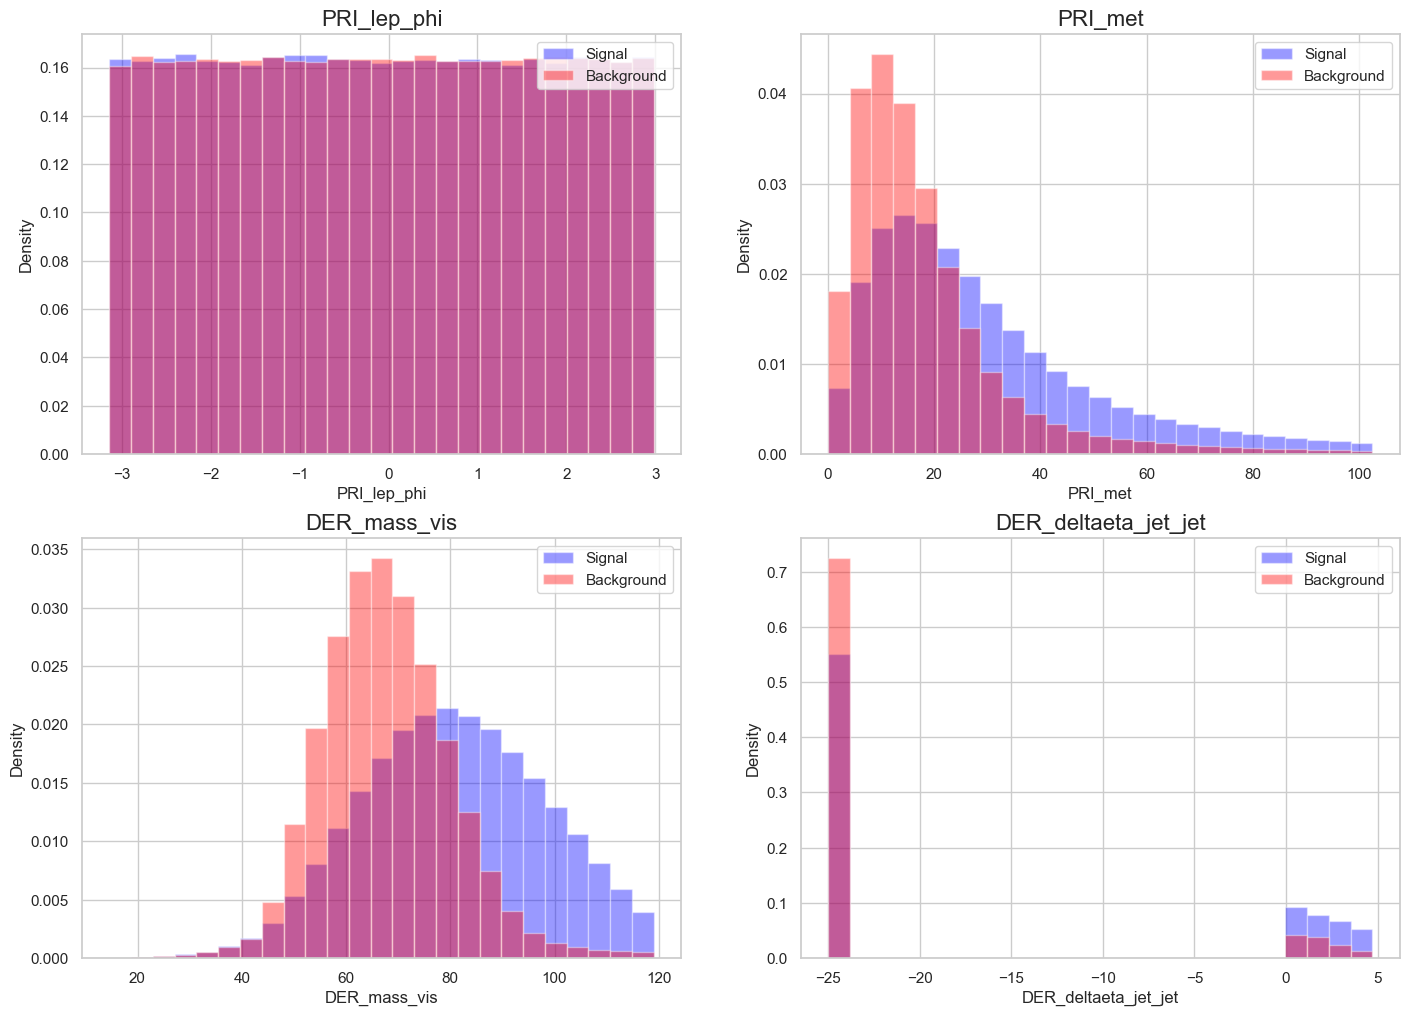

In [91]:
from utils import histogram_dataset

# this function is defined in utils.py in the sample_code_submission directory. feel free to modify it as needed

histogram_dataset(
    data_set,
    target,
    weights,
    columns=["PRI_lep_phi", "PRI_met", "DER_mass_vis", "DER_deltaeta_jet_jet"],
)

Signal feature  correlation matrix


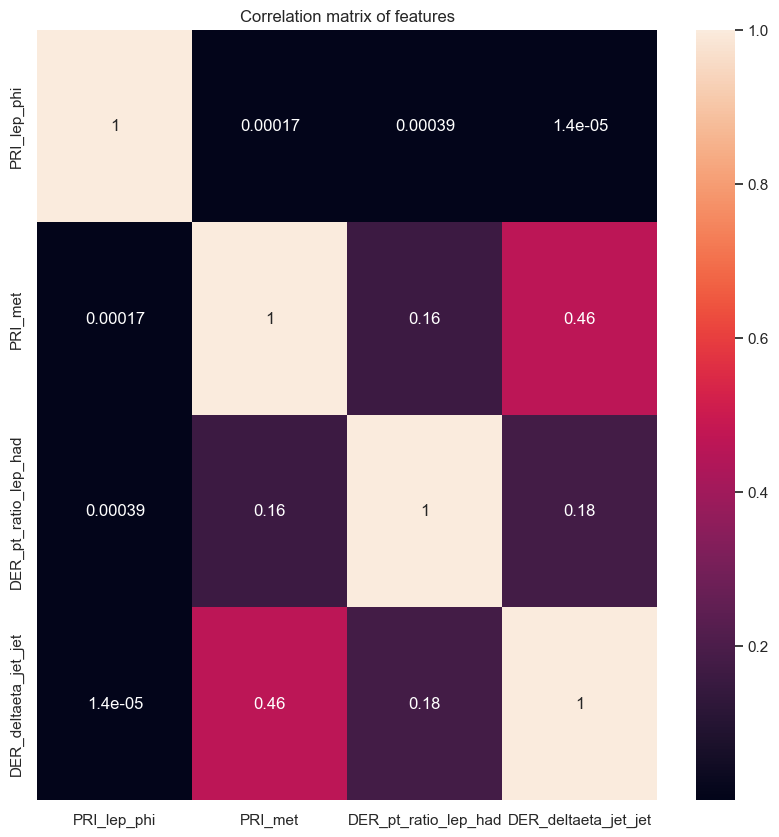

Background feature  correlation matrix


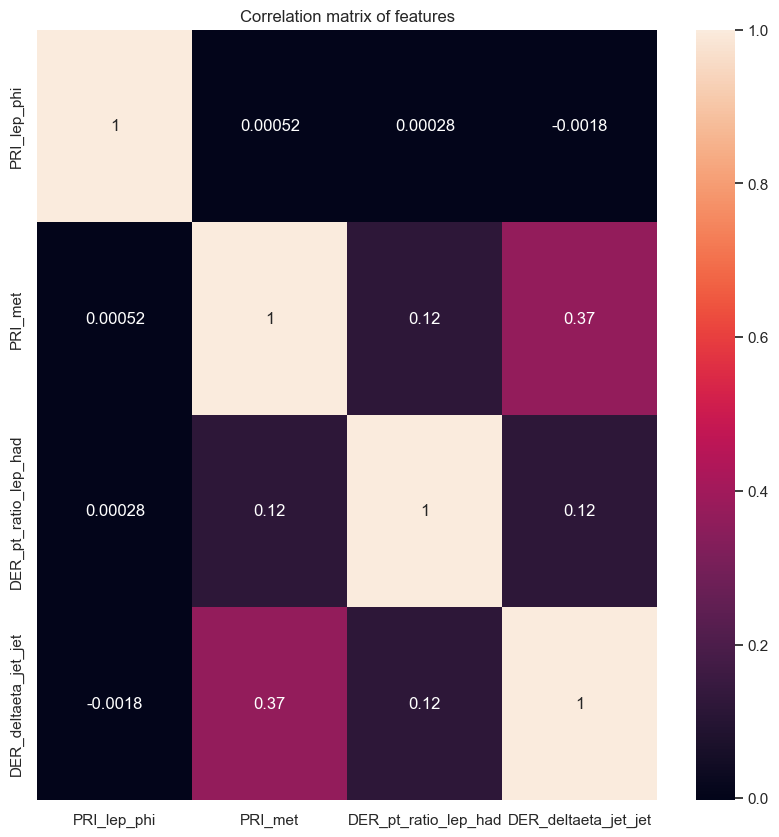

In [92]:
import seaborn as sns

sns.set_theme(rc={"figure.figsize": (10, 10)}, style="whitegrid")

caption = ["Signal feature", "Background feature"]

for i in range(2):

    dfplot = pd.DataFrame(
        data_set,
        columns=[
            "PRI_lep_phi",
            "PRI_met",
            "DER_pt_ratio_lep_had",
            "DER_deltaeta_jet_jet",
        ],
    )

    print(caption[i], " correlation matrix")
    corrMatrix = dfplot[target == i].corr()
    sns.heatmap(corrMatrix, annot=True)
    plt.title("Correlation matrix of features")
    plt.show()

del dfplot

keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


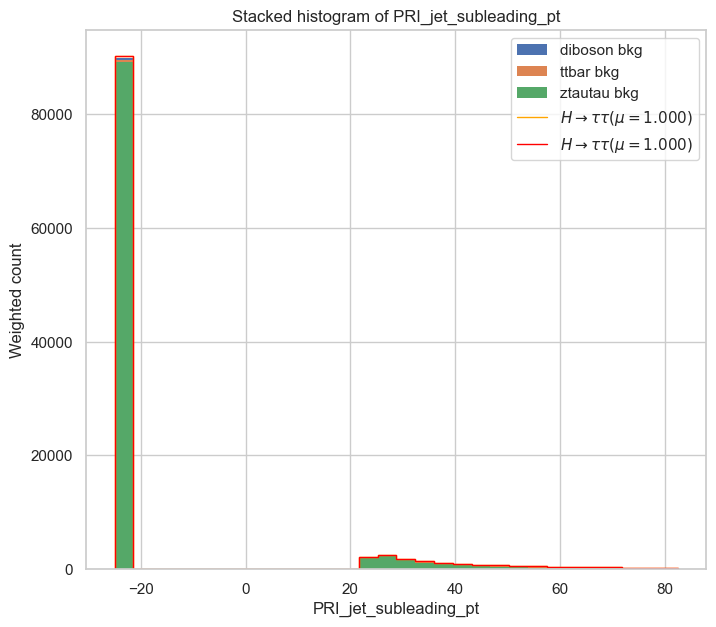

In [93]:
from HiggsML.visualization import stacked_histogram

stacked_histogram(data_set, target, weights, detailed_label, "PRI_jet_subleading_pt")

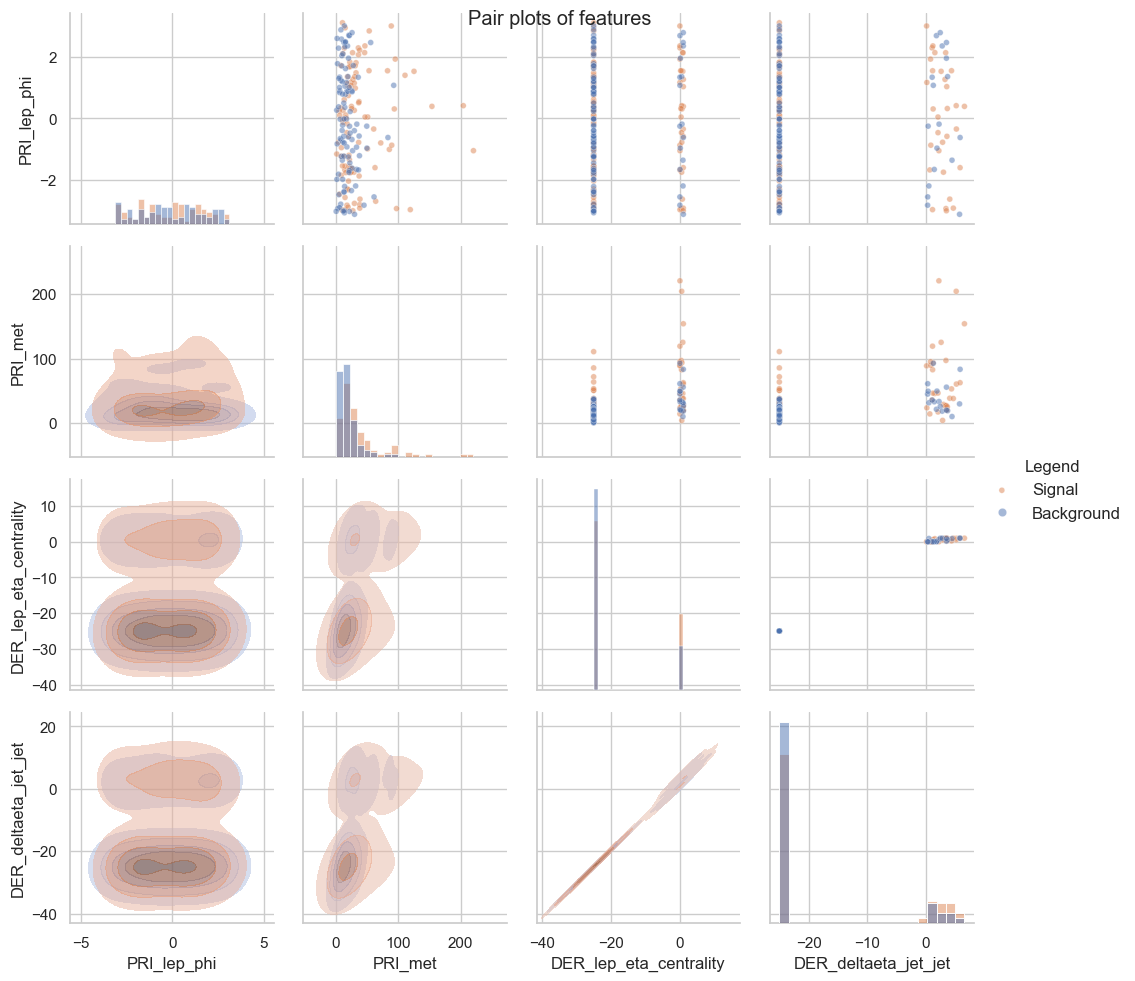

In [94]:
from HiggsML.visualization import pair_plots

# Show data summary
pair_plots(
    data_set,
    target,
    sample_size=100,
    columns=[
        "PRI_lep_phi",
        "PRI_met",
        "DER_lep_eta_centrality",
        "DER_deltaeta_jet_jet",
    ],
)

---
## Feature Analysis

### Étape 1 — Distribution de toutes les features (Signal vs Background)

On trace les histogrammes de toutes les features du dataset, séparées en deux groupes :
- **Features PRI** : mesures brutes du détecteur
- **Features DER** : quantités dérivées calculées à partir des PRI

L'objectif est d'identifier visuellement quelles features discriminent le mieux signal (bleu) et background (rouge).

=== Features PRI (mesures brutes) ===
[*] --- PRI_lep_pt histogram
[*] --- PRI_lep_eta histogram
[*] --- PRI_lep_phi histogram
[*] --- PRI_had_pt histogram
[*] --- PRI_had_eta histogram
[*] --- PRI_had_phi histogram
[*] --- PRI_jet_leading_pt histogram
[*] --- PRI_jet_leading_eta histogram
[*] --- PRI_jet_leading_phi histogram
[*] --- PRI_jet_subleading_pt histogram
[*] --- PRI_jet_subleading_eta histogram
[*] --- PRI_jet_subleading_phi histogram
[*] --- PRI_n_jets histogram
[*] --- PRI_jet_all_pt histogram
[*] --- PRI_met histogram
[*] --- PRI_met_phi histogram


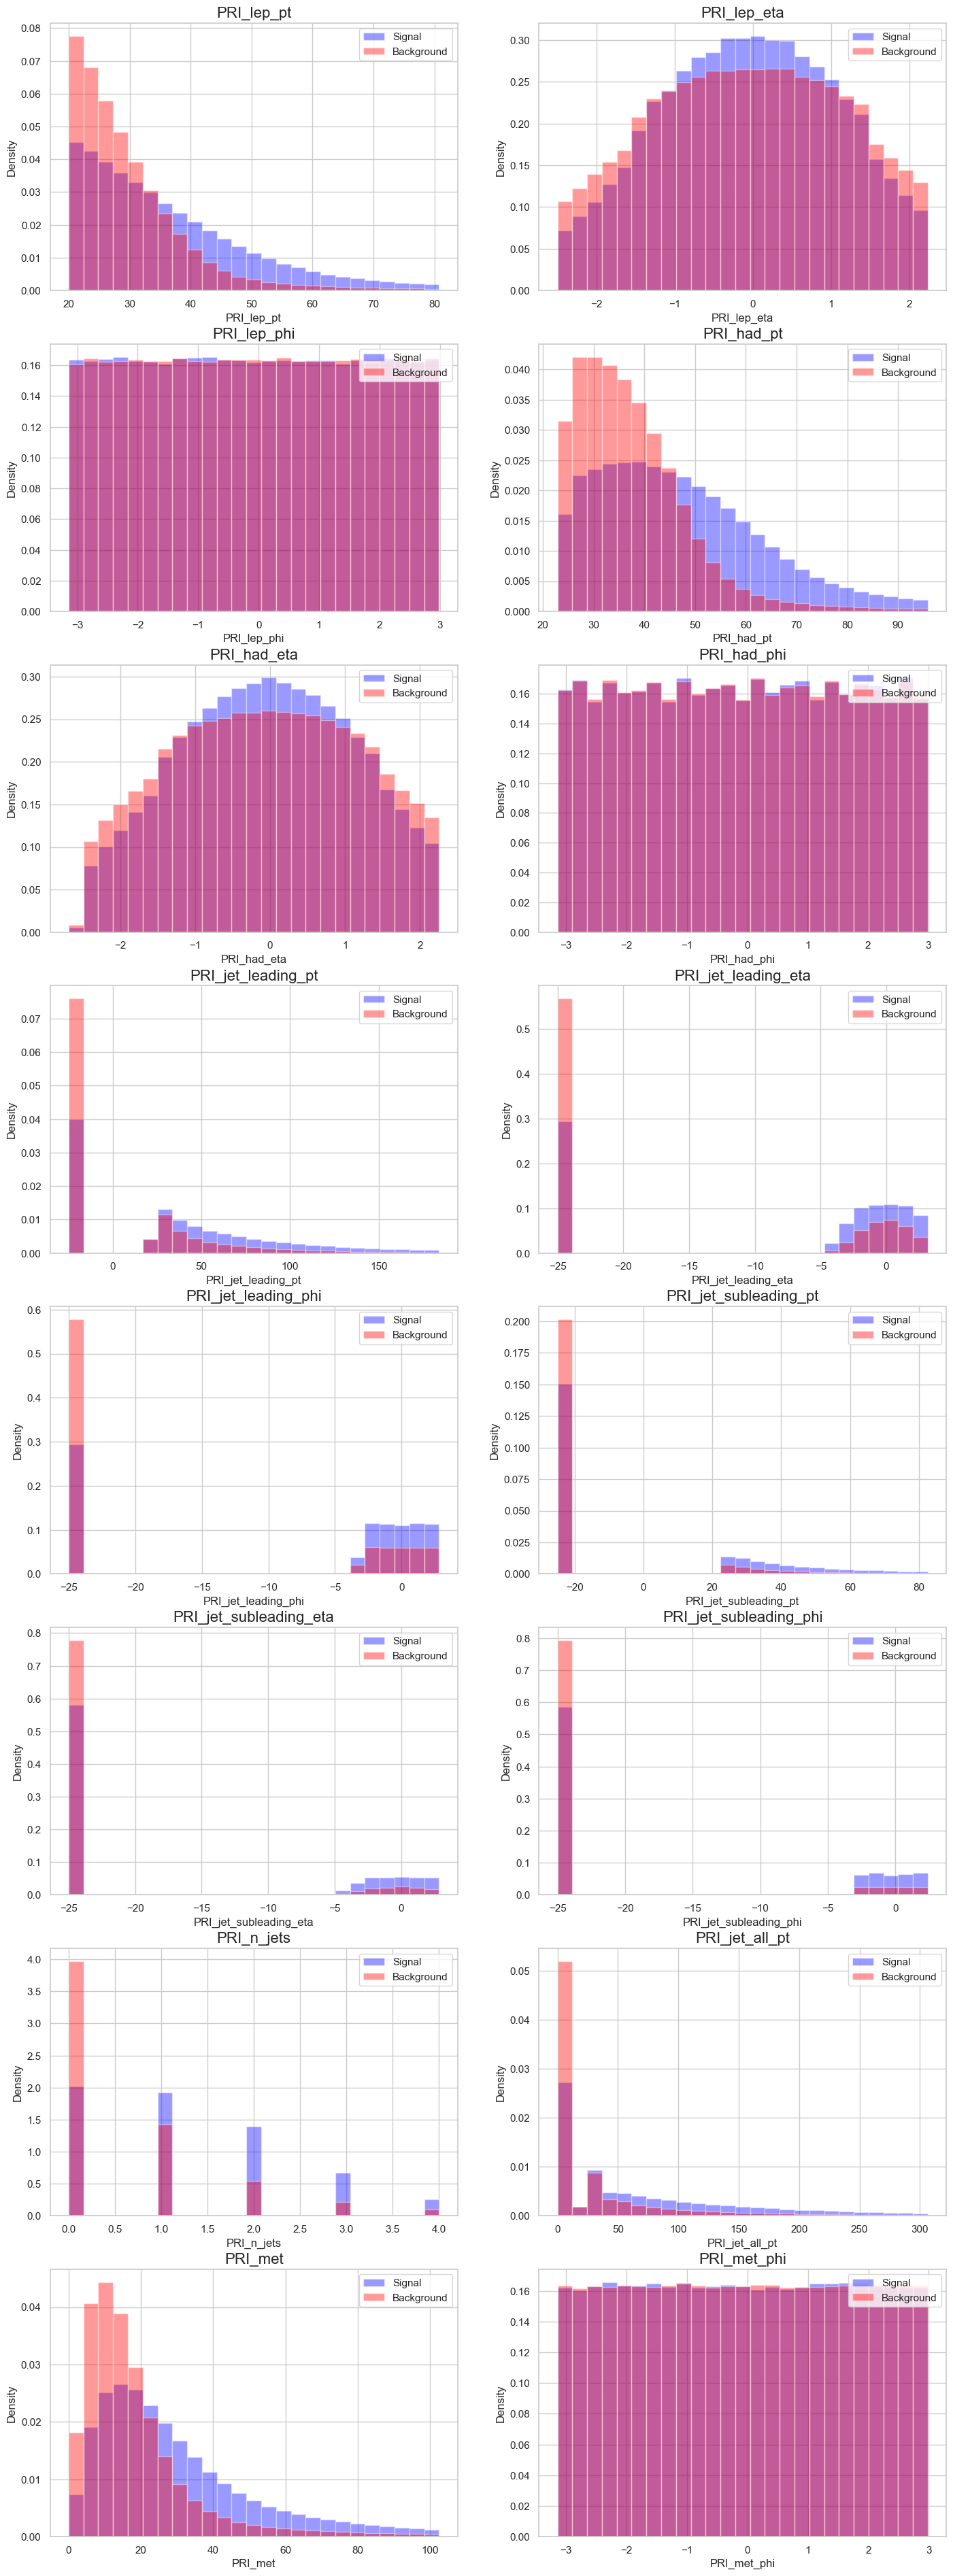

In [95]:
from utils import histogram_dataset

# Features PRI : mesures brutes du détecteur
PRI_features = [
    "PRI_lep_pt", "PRI_lep_eta", "PRI_lep_phi",
    "PRI_had_pt", "PRI_had_eta", "PRI_had_phi",
    "PRI_jet_leading_pt", "PRI_jet_leading_eta", "PRI_jet_leading_phi",
    "PRI_jet_subleading_pt", "PRI_jet_subleading_eta", "PRI_jet_subleading_phi",
    "PRI_n_jets", "PRI_jet_all_pt", "PRI_met", "PRI_met_phi",
]

print("=== Features PRI (mesures brutes) ===")
histogram_dataset(data_set, target, weights, columns=PRI_features)

=== Features DER (quantités dérivées) ===
[*] --- DER_mass_transverse_met_lep histogram
[*] --- DER_mass_vis histogram
[*] --- DER_pt_h histogram
[*] --- DER_deltaeta_jet_jet histogram
[*] --- DER_mass_jet_jet histogram
[*] --- DER_prodeta_jet_jet histogram
[*] --- DER_deltar_had_lep histogram
[*] --- DER_pt_tot histogram
[*] --- DER_sum_pt histogram
[*] --- DER_pt_ratio_lep_had histogram
[*] --- DER_met_phi_centrality histogram
[*] --- DER_lep_eta_centrality histogram


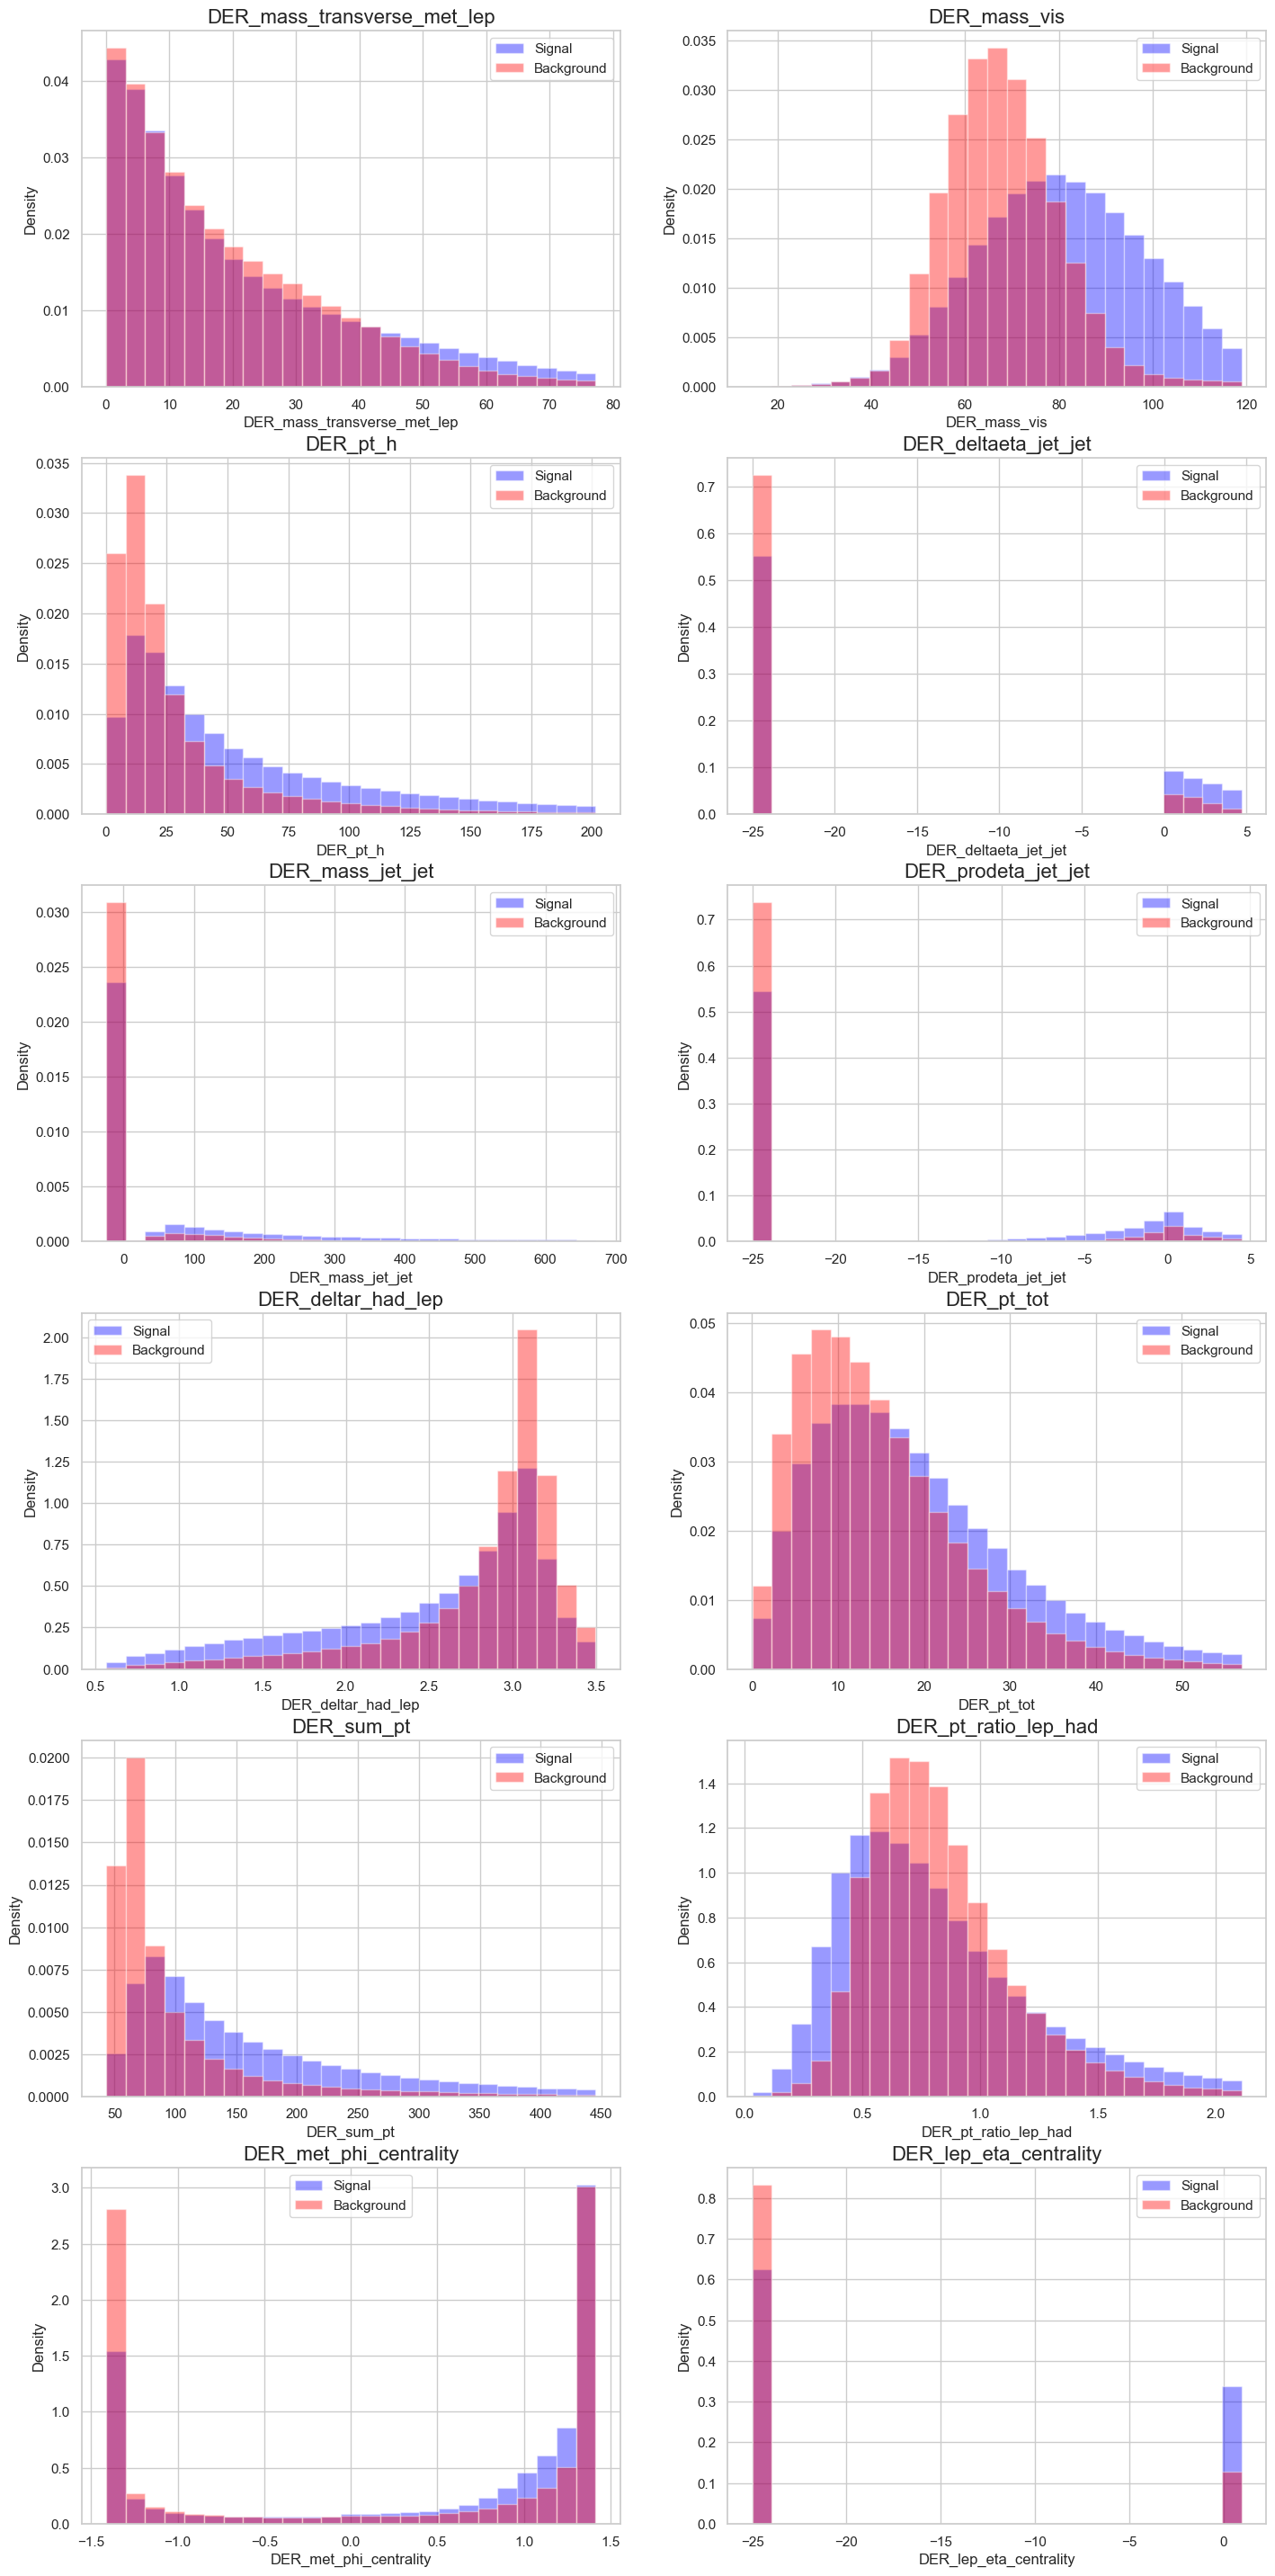

In [96]:
# Features DER : quantités dérivées
DER_features = [
    "DER_mass_transverse_met_lep", "DER_mass_vis", "DER_pt_h",
    "DER_deltaeta_jet_jet", "DER_mass_jet_jet", "DER_prodeta_jet_jet",
    "DER_deltar_had_lep", "DER_pt_tot", "DER_sum_pt",
    "DER_pt_ratio_lep_had", "DER_met_phi_centrality", "DER_lep_eta_centrality",
]

print("=== Features DER (quantités dérivées) ===")
histogram_dataset(data_set, target, weights, columns=DER_features)

### Etape 2 --- Correlations entre features

On calcule la matrice de correlation de Pearson entre toutes les features :
1. **Vue globale** : heatmap complete (28 features x 28 features) pour signal et background
2. **Vue ciblee** : correlations croisees DER vs PRI pour comprendre quelles features derivees sont redondantes avec les mesures brutes

In [ ]:
import seaborn as sns

feature_cols = [c for c in data_set.columns if c not in ["weights", "labels", "detailed_labels"]]

# Matrice de correlation complete signal et background
fig, axes = plt.subplots(1, 2, figsize=(26, 22))

for ax, (label_val, label_name) in zip(axes, [(1, "Signal"), (0, "Background")]):
    corr = data_set[feature_cols][target == label_val].corr()
    sns.heatmap(corr, annot=False, cmap="coolwarm", center=0,
                linewidths=0.3, ax=ax, vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True)
    ax.set_title(f"Matrice de correlation --- {label_name}", fontsize=14)
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

In [ ]:
feature_cols = [c for c in data_set.columns if c not in ["weights", "labels", "detailed_labels"]]
PRI_cols = [c for c in feature_cols if c.startswith("PRI_")]
DER_cols = [c for c in feature_cols if c.startswith("DER_")]

# Correlations croisees DER vs PRI
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (label_val, label_name) in zip(axes, [(1, "Signal"), (0, "Background")]):
    subset = data_set[PRI_cols + DER_cols][target == label_val]
    cross_corr = subset.corr().loc[DER_cols, PRI_cols]
    sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                linewidths=0.3, ax=ax, vmin=-1, vmax=1, annot_kws={"size": 7})
    ax.set_title(f"Correlations DER vs PRI --- {label_name}", fontsize=13)

plt.tight_layout()
plt.show()

### Etape 3 --- Feature Engineering

On teste deux transformations et on compare l AUC du BDT avant/apres :
1. **Angles phi** : remplacer  par  et  (les angles sont periodiques, le BDT ne gere pas la periodicite)
2. **Coordonnees cartesiennes** : remplacer (pt, eta, phi) par (Px, Py, Pz) avec :
   - , , 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from boosted_decision_tree import BoostedDecisionTree

feature_cols = [c for c in data_set.columns if c not in ["weights", "labels", "detailed_labels"]]

X = data_set[feature_cols].values
y = target.values
w = weights.values

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=42, stratify=y
)

bdt_baseline = BoostedDecisionTree(None)
bdt_baseline.fit(X_train, y_train, w_train)
score_baseline = bdt_baseline.predict(X_test)
auc_baseline = roc_auc_score(y_test, score_baseline, sample_weight=w_test)
print(f"AUC baseline (features originales) : {auc_baseline:.4f}")

In [ ]:
# Transformation 1 : remplacer PRI_X_phi par cos(phi) et sin(phi)
phi_cols = [c for c in feature_cols if c.endswith("_phi")]
non_phi_cols = [c for c in feature_cols if not c.endswith("_phi")]

df_phi = data_set[non_phi_cols].copy()
for col in phi_cols:
    df_phi[col.replace("_phi", "_cos_phi")] = np.cos(data_set[col])
    df_phi[col.replace("_phi", "_sin_phi")] = np.sin(data_set[col])

X_phi = df_phi.values
X_phi_train, X_phi_test, _, _, _, _ = train_test_split(
    X_phi, y, w, test_size=0.2, random_state=42, stratify=y
)

bdt_phi = BoostedDecisionTree(None)
bdt_phi.fit(X_phi_train, y_train, w_train)
score_phi = bdt_phi.predict(X_phi_test)
auc_phi = roc_auc_score(y_test, score_phi, sample_weight=w_test)
print(f"AUC baseline                    : {auc_baseline:.4f}")
print(f"AUC phi -> cos/sin              : {auc_phi:.4f}  (delta={auc_phi - auc_baseline:+.4f})")

In [ ]:
# Transformation 2 : remplacer (pt, eta, phi) par (Px, Py, Pz)
particles = ["lep", "had", "jet_leading", "jet_subleading"]
cols_to_drop = []
df_cart = data_set[feature_cols].copy()

for p in particles:
    pt_col  = f"PRI_{p}_pt"
    eta_col = f"PRI_{p}_eta"
    phi_col = f"PRI_{p}_phi"
    if pt_col in df_cart.columns:
        df_cart[f"PRI_{p}_px"] = df_cart[pt_col] * np.cos(df_cart[phi_col])
        df_cart[f"PRI_{p}_py"] = df_cart[pt_col] * np.sin(df_cart[phi_col])
        df_cart[f"PRI_{p}_pz"] = df_cart[pt_col] * np.sinh(df_cart[eta_col])
        cols_to_drop += [pt_col, eta_col, phi_col]

df_cart = df_cart.drop(columns=cols_to_drop)

X_cart = df_cart.values
X_cart_train, X_cart_test, _, _, _, _ = train_test_split(
    X_cart, y, w, test_size=0.2, random_state=42, stratify=y
)

bdt_cart = BoostedDecisionTree(None)
bdt_cart.fit(X_cart_train, y_train, w_train)
score_cart = bdt_cart.predict(X_cart_test)
auc_cart = roc_auc_score(y_test, score_cart, sample_weight=w_test)
print(f"AUC baseline                    : {auc_baseline:.4f}")
print(f"AUC phi -> cos/sin              : {auc_phi:.4f}  (delta={auc_phi - auc_baseline:+.4f})")
print(f"AUC (pt,eta,phi) -> (Px,Py,Pz)  : {auc_cart:.4f}  (delta={auc_cart - auc_baseline:+.4f})")

In [ ]:
from sklearn.metrics import roc_curve

# Comparaison des courbes ROC
fig, ax = plt.subplots(figsize=(8, 7))

for score, label, color in [
    (score_baseline, f"Baseline  AUC={auc_baseline:.3f}", "b"),
    (score_phi,      f"cos/sin phi  AUC={auc_phi:.3f}", "g"),
    (score_cart,     f"Px Py Pz  AUC={auc_cart:.3f}", "r"),
]:
    fpr, tpr, _ = roc_curve(y_test, score, sample_weight=w_test)
    ax.plot(fpr, tpr, label=label, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Comparaison ROC --- Feature Engineering")
ax.legend()
plt.show()

### Etape 4 --- Impact des biais systematiques sur chaque feature

On fait varier les parametres systematiques (TES = tau energy scale, JES = jet energy scale)
et on mesure pour chaque feature le decalage de distribution via le **test KS** (Kolmogorov-Smirnov).
Un KS eleve signifie que la feature est tres sensible au systematique => a eviter ou a traiter avec soin.

In [ ]:
from HiggsML.systematics import systematics
from scipy.stats import ks_2samp

feature_cols = [c for c in data_set.columns if c not in ["weights", "labels", "detailed_labels"]]

train_set = {
    "data": data_set[feature_cols],
    "labels": target.values,
    "weights": weights.values,
    "detailed_labels": data_set["detailed_labels"].values,
}

# Appliquer TES=0.9 et TES=1.1
syst_tes_down = systematics(train_set, tes=0.9)
syst_tes_up   = systematics(train_set, tes=1.1)

df_nom      = data_set[feature_cols].reset_index(drop=True)
df_tes_down = pd.DataFrame(syst_tes_down["data"], columns=feature_cols)
df_tes_up   = pd.DataFrame(syst_tes_up["data"],   columns=feature_cols)

# Calcul du KS pour chaque feature
ks_tes = {}
for col in feature_cols:
    ks_down, _ = ks_2samp(df_nom[col], df_tes_down[col])
    ks_up,   _ = ks_2samp(df_nom[col], df_tes_up[col])
    ks_tes[col] = max(ks_down, ks_up)

ks_tes_series = pd.Series(ks_tes).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ks_tes_series.plot(kind="bar", ax=ax, color=["steelblue" if v < 0.05 else "tomato" for v in ks_tes_series])
ax.axhline(0.05, color="k", linestyle="--", label="seuil KS=0.05")
ax.set_title("Sensibilite des features au TES (KS statistic)")
ax.set_ylabel("KS statistic")
ax.set_xlabel("Feature")
ax.tick_params(axis="x", rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Appliquer JES=0.9 et JES=1.1
syst_jes_down = systematics(train_set, jes=0.9)
syst_jes_up   = systematics(train_set, jes=1.1)

df_jes_down = pd.DataFrame(syst_jes_down["data"], columns=feature_cols)
df_jes_up   = pd.DataFrame(syst_jes_up["data"],   columns=feature_cols)

ks_jes = {}
for col in feature_cols:
    ks_down, _ = ks_2samp(df_nom[col], df_jes_down[col])
    ks_up,   _ = ks_2samp(df_nom[col], df_jes_up[col])
    ks_jes[col] = max(ks_down, ks_up)

ks_jes_series = pd.Series(ks_jes).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ks_jes_series.plot(kind="bar", ax=ax, color=["steelblue" if v < 0.05 else "tomato" for v in ks_jes_series])
ax.axhline(0.05, color="k", linestyle="--", label="seuil KS=0.05")
ax.set_title("Sensibilite des features au JES (KS statistic)")
ax.set_ylabel("KS statistic")
ax.set_xlabel("Feature")
ax.tick_params(axis="x", rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Synthese : features les plus stables (faible KS pour TES et JES)
df_sensitivity = pd.DataFrame({
    "KS_TES": ks_tes_series,
    "KS_JES": ks_jes_series,
})
df_sensitivity["KS_max"] = df_sensitivity.max(axis=1)
df_sensitivity = df_sensitivity.sort_values("KS_max")

print("Features les plus stables (faible sensibilite aux systematiques) :")
print(df_sensitivity.head(10).to_string())
print()
print("Features les plus sensibles :")
print(df_sensitivity.tail(10).to_string())

### Ingestion



In [97]:
from HiggsML.ingestion import Ingestion

ingestion = Ingestion(data)

In [98]:
# initialize submission
ingestion.init_submission(Model,"BDT")

2026-06-02 14:33:24,444 - HiggsML.ingestion    - INFO     - Initializing Submmited Model
2026-06-02 14:33:24,450 - HiggsML.datasets     - INFO     - Selected train size: 5000
2026-06-02 14:33:25,234 - HiggsML.datasets     - INFO     - Data loaded successfully
2026-06-02 14:33:25,267 - HiggsML.datasets     - INFO     - Selected train size: 5000


Training Data:  (5000, 28)
Training Labels:  (5000,)
Training Weights:  (5000,)
sum_signal_weights:  687.7458062150929
sum_bkg_weights:  105031.2541937849


2026-06-02 14:33:26,022 - HiggsML.datasets     - INFO     - Data loaded successfully
2026-06-02 14:33:26,057 - HiggsML.datasets     - INFO     - Selected train size: 5000



Valid Data:  (5000, 28)
Valid Labels:  (5000,)
Valid Weights:  (5000,)
sum_signal_weights:  665.2622550501835
sum_bkg_weights:  105053.73774494979


2026-06-02 14:33:26,840 - HiggsML.datasets     - INFO     - Data loaded successfully



Holdout Data:  (5000, 28)
Holdout Labels:  (5000,)
Holdout Weights:  (5000,)
sum_signal_weights:  648.6976377022909
sum_bkg_weights:  105070.30236229772
 
 
Training Data:  (5000, 28)
DEBUG: model_type = 'BDT'
 Model is BDT


2026-06-02 14:33:26,898 - HiggsML.ingestion    - INFO     - Calling fit method of submitted model


score shape before threshold (4576,)
score shape after threshold (4576,)
saved_info {'beta': np.float64(12452.314505210927), 'gamma': np.float64(415.4060174706904), 'tes_fit': <function tes_fitter.<locals>.fit_function at 0x000001FC48DB6AC0>, 'jes_fit': <function jes_fitter.<locals>.fit_function at 0x000001FC48DB6A20>}
Train Results: 
	 mu_hat  :  -27.58565703273331
	 del_mu_stat  :  0.27307253786251534
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.27307253786251534
Holdout Results: 
	 mu_hat  :  0.9999999999999993
	 del_mu_stat  :  0.27307253786251534
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.27307253786251534
Valid Results: 
	 mu_hat  :  3.4056664227453988
	 del_mu_stat  :  0.27307253786251534
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.27307253786251534
[*] --- score histogram


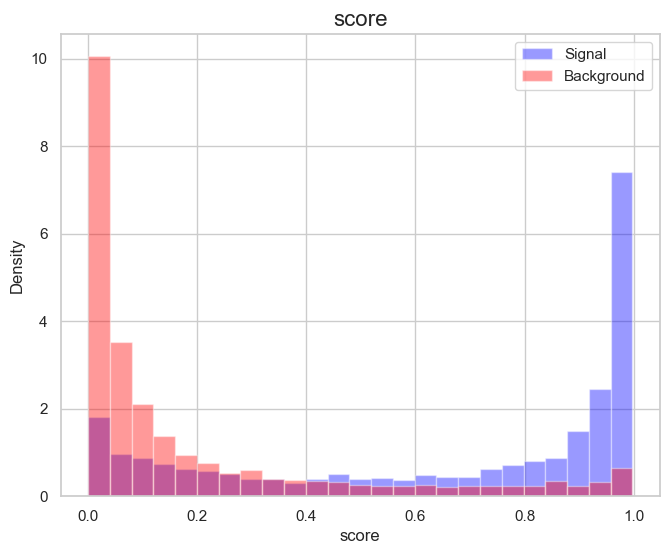

keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


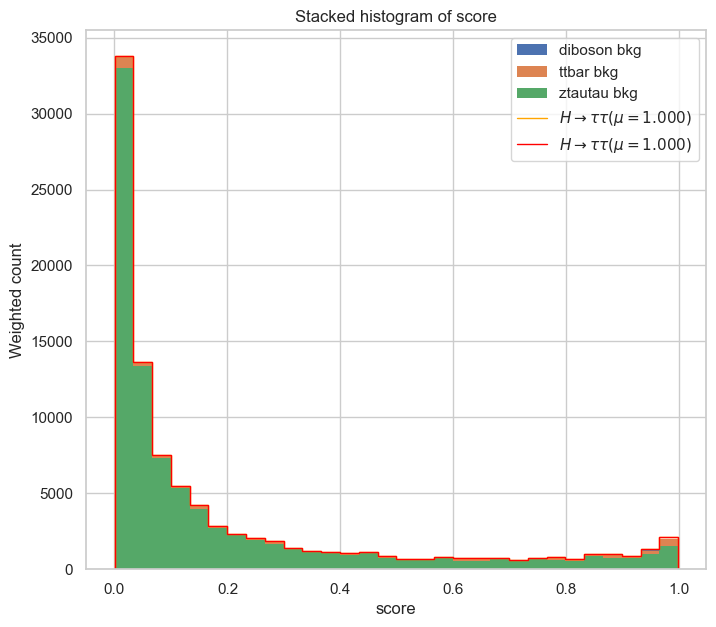

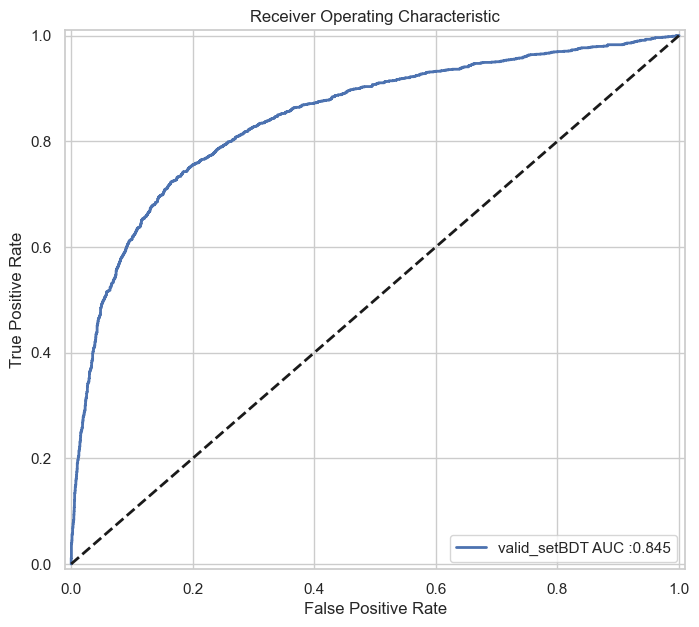

In [99]:
# fit submission
ingestion.fit_submission()

In [100]:
# load test set
data.load_test_set()

2026-06-02 14:33:32,818 - HiggsML.datasets     - INFO     - Data loaded successfully
2026-06-02 14:33:33,481 - HiggsML.datasets     - INFO     - Test data loaded successfully


### Test Settings
The Test setting sets the test conditions in ingestion.
This includes what systematics you want and how many psuedo experiments you want. 

In [101]:
test_settings = {
    "systematics": {  # Systematics to use
        "tes": False,  # tau energy scasle
        "jes": False,  # jet energy scale
        "soft_met": False,  # soft term in MET
        "ttbar_scale": False,  # W boson scale factor
        "diboson_scale": False,  # Diboson scale factor
        "bkg_scale": False,  # Background scale factor
    },
    "num_pseudo_experiments": 500,  # Number of pseudo-experiments to run per set
    "num_of_sets": 1,  # Number of sets of pseudo-experiments to run
}

RANDOM_SEED = 42

random_state = np.random.RandomState(RANDOM_SEED)
test_settings["ground_truth_mus"] = (
    random_state.uniform(0.1, 3, test_settings["num_of_sets"])
).tolist()

random_settings_file = os.path.join(output_dir, "test_settings.json")
with open(random_settings_file, "w") as f:
    json.dump(test_settings, f)

In [102]:
# predict submission
ingestion.predict_submission(test_settings)

2026-06-02 14:33:33,559 - HiggsML.ingestion    - INFO     - Calling predict method of submitted model with seed: 31415


Test Results:  {'mu_hat': np.float64(2.979459715882426), 'del_mu_stat': np.float64(0.27307253786251534), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27307253786251534)}
Test Results:  {'mu_hat': np.float64(3.304442971594472), 'del_mu_stat': np.float64(0.27307253786251534), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27307253786251534)}
Test Results:  {'mu_hat': np.float64(2.6496618934190903), 'del_mu_stat': np.float64(0.27307253786251534), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27307253786251534)}
Test Results:  {'mu_hat': np.float64(2.721880394688434), 'del_mu_stat': np.float64(0.27307253786251534), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27307253786251534)}
Test Results:  {'mu_hat': np.float64(3.3742541894881706), 'del_mu_stat': np.float64(0.27307253786251534), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27307253786251534)}
Test Results:  {'mu_hat': np.float64(3.0444563670248352), 'del_mu_stat': np.float64

In [103]:
ingestion.process_results_dict()

In [104]:
# save result
ingestion.save_result(output_dir)

## Score
1. Compute Scores
2. Visualize Scores


In [105]:
from HiggsML.score import Scoring

In [106]:
# Initialize Score
score = Scoring()

In [107]:
print(output_dir)
score.load_ingestion_results(prediction_dir=output_dir, score_dir=output_dir)

2026-06-02 14:38:18,029 - HiggsML.score        - INFO     - Read ingestion results from c:\Users\Louis Boulin\OneDrive\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission


c:\Users\Louis Boulin\OneDrive\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission


2026-06-02 14:38:18,040 - HiggsML.score        - INFO     - Computing scores


[✔]


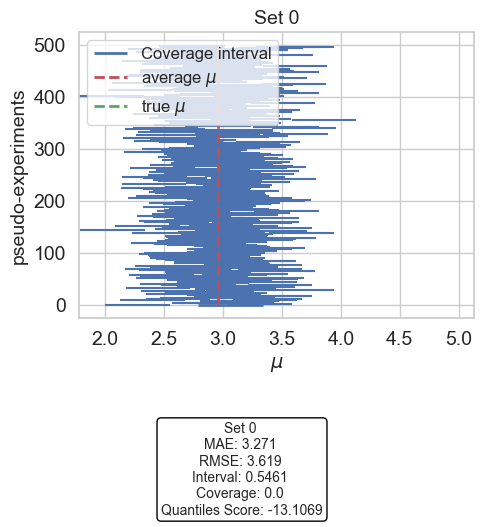

In [108]:
# Compute Score
score.compute_scores(test_settings)

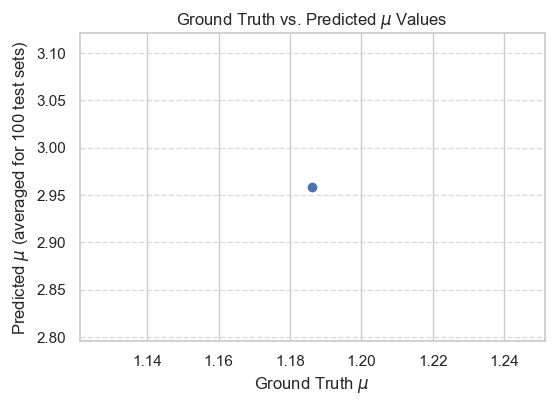

In [109]:
from HiggsML.visualization import visualize_scatter

# Visualize scatter plot of ground truth mu and predicted mu
visualize_scatter(
    ingestion_result_dict=ingestion.results_dict,
    ground_truth_mus=test_settings["ground_truth_mus"],
)

In [110]:
!python -m HiggsML.score --prediction $output_dir --output $output_dir

############################################
### Scoring Program
############################################



usage: score.py [-h] [--prediction PREDICTION] [--output OUTPUT]
                [--reference REFERENCE] [--codabench]
score.py: error: unrecognized arguments: Boulin\OneDrive\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission Boulin\OneDrive\Documents\GitHub\Higgs-TeamB\Higgs_collaborations-main\sample_result_submission
